# 🍎 Segmentación de Imágenes de Frutas con Características Avanzadas

Procesamiento mejorado de imágenes para mejor clasificación de frutas usando segmentación de fondo y extracción de características robustas.

## 1️⃣ Importar Librerías Necesarias

In [1]:
%load_ext autoreload
%autoreload 2

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure
import warnings
warnings.filterwarnings('ignore')

## 2️⃣ Cargar Imágenes desde Carpetas

In [2]:
# Cargar imágenes desde las subcarpetas
root_dir = "/home/bruno/fing/IA_I/img/"
images = []
labels = []

print("Cargando imágenes...\n")

for clase in sorted(os.listdir(root_dir)):
    clase_path = os.path.join(root_dir, clase)
    if not os.path.isdir(clase_path):
        continue
    
    count = 0
    for filename in os.listdir(clase_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(clase_path, filename)
            bgr = cv2.imread(img_path)
            
            if bgr is not None:
                rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
                images.append(rgb)
                labels.append(clase)
                count += 1
    
    print(f"✓ {clase}: {count} imágenes cargadas")

print(f"\nTotal de imágenes: {len(images)}")
print(f"Clases: {np.unique(labels)}")

Cargando imágenes...

✓ banana: 1 imágenes cargadas
✓ manzana: 1 imágenes cargadas
✓ naranja: 1 imágenes cargadas
✓ pera: 1 imágenes cargadas
✓ test_fruta: 1 imágenes cargadas

Total de imágenes: 5
Clases: ['banana' 'manzana' 'naranja' 'pera' 'test_fruta']


## 3️⃣ Procesar Imagen: Redimensión, Difuminado y Conversión HSV

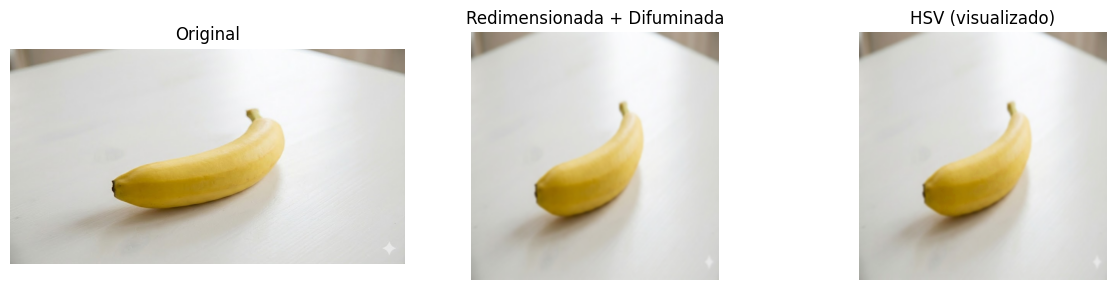

In [3]:
def preprocess_image(rgb_image, size=(300, 300)):
    """
    Preprocesa la imagen: redimensiona, difumina y convierte a HSV.
    
    Parámetros:
    - rgb_image: imagen en RGB
    - size: tamaño de redimensionamiento
    
    Retorna:
    - rgb_resized: imagen redimensionada en RGB
    - hsv: imagen en espacio HSV
    """
    # Redimensionar
    rgb_resized = cv2.resize(rgb_image, size)
    
    # Difuminado Gaussiano
    rgb_blurred = cv2.GaussianBlur(rgb_resized, (5, 5), 0)
    
    # Convertir a HSV
    bgr_blurred = cv2.cvtColor(rgb_blurred, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr_blurred, cv2.COLOR_BGR2HSV)
    
    return rgb_resized, hsv, rgb_blurred


# Probar con una imagen
rgb_example = images[0]
rgb_prep, hsv_prep, rgb_blur = preprocess_image(rgb_example)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(rgb_example)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(rgb_blur)
axes[1].set_title("Redimensionada + Difuminada")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(hsv_prep, cv2.COLOR_HSV2RGB))
axes[2].set_title("HSV (visualizado)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4️⃣ Segmentación del Fondo Blanco

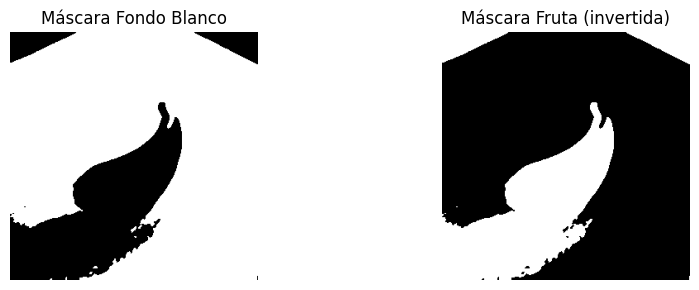

In [4]:
def create_background_mask(hsv_image):
    """
    Crea máscara para segmentar el fondo blanco.
    El fondo blanco tiene baja saturación (S bajo) y alto valor (V alto).
    
    Retorna:
    - mask_bg: máscara del fondo blanco (1 = fondo, 0 = fruta)
    """
    h, s, v = cv2.split(hsv_image)
    
    # Fondo blanco: S < 50 y V > 200
    mask_bg = (s < 50) & (v > 200)
    
    return mask_bg.astype(np.uint8) * 255


# Probar con la imagen de ejemplo
mask_bg = create_background_mask(hsv_prep)
mask_fg = 255 - mask_bg  # Invertir para obtener máscara de fruta

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(mask_bg, cmap='gray')
axes[0].set_title("Máscara Fondo Blanco")
axes[0].axis('off')

axes[1].imshow(mask_fg, cmap='gray')
axes[1].set_title("Máscara Fruta (invertida)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5️⃣ Filtrado de Contornos y Aplicación de Máscara

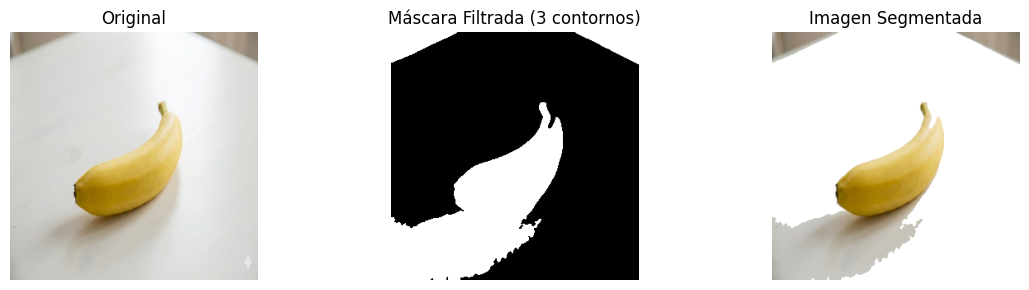

In [5]:
def filter_contours_and_segment(rgb_image, mask_fg, min_area=500):
    """
    Detecta contornos, filtra por área y aplica máscara.
    
    Retorna:
    - segmented_image: imagen sin fondo (RGB)
    - mask_final: máscara filtrada
    - contours: contornos detectados
    """
    # Encontrar contornos
    contours, _ = cv2.findContours(mask_fg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Crear máscara final vacía
    mask_final = np.zeros_like(mask_fg, dtype=np.uint8)
    
    # Filtrar contornos por área
    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > min_area:
            valid_contours.append(contour)
            cv2.drawContours(mask_final, [contour], 0, 255, -1)
    
    # Aplicar máscara a la imagen
    segmented = rgb_image.copy()
    segmented[mask_final == 0] = 255  # Fondo blanco
    
    return segmented, mask_final, valid_contours


# Probar con la imagen de ejemplo
segmented_img, mask_final, contours = filter_contours_and_segment(rgb_prep, mask_fg, min_area=500)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(rgb_prep)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask_final, cmap='gray')
axes[1].set_title(f"Máscara Filtrada ({len(contours)} contornos)")
axes[1].axis('off')

axes[2].imshow(segmented_img)
axes[2].set_title("Imagen Segmentada")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 6️⃣ Extracción de Características del Contorno

In [6]:
def extract_features(rgb_image, hsv_image, mask_final, contour):
    """
    Extrae características del contorno detectado.
    
    Características:
    - aspect_ratio: relación ancho/alto
    - area: área del contorno
    - perimeter: perímetro
    - circularity: qué tan circular (4π*area/perímetro²)
    - hue_mean: promedio del canal H
    - hsv_mean: promedio de H, S, V
    - hu_moments: momentos de Hu (7 valores)
    """
    
    # Aspect Ratio
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = float(w) / h if h > 0 else 0
    
    # Área
    area = cv2.contourArea(contour)
    
    # Perímetro
    perimeter = cv2.arcLength(contour, True)
    
    # Circularidad
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    
    # Momentos de Hu
    moments = cv2.HuMoments(contour).flatten()
    
    # Extraer píxeles de la fruta para calcular promedios de color
    h_channel, s_channel, v_channel = cv2.split(hsv_image)
    
    # Crear máscara de este contorno específico
    contour_mask = np.zeros_like(mask_final, dtype=np.uint8)
    cv2.drawContours(contour_mask, [contour], 0, 255, -1)
    
    # Píxeles dentro del contorno
    pixels_h = h_channel[contour_mask == 255]
    pixels_s = s_channel[contour_mask == 255]
    pixels_v = v_channel[contour_mask == 255]
    
    hue_mean = float(np.mean(pixels_h)) if len(pixels_h) > 0 else 0
    sat_mean = float(np.mean(pixels_s)) if len(pixels_s) > 0 else 0
    val_mean = float(np.mean(pixels_v)) if len(pixels_v) > 0 else 0
    
    # Histograma del canal H (usar primeros 8 bins para simplificar)
    hist_h = cv2.calcHist([h_channel], [0], contour_mask, [8], [0, 180])
    hist_h = hist_h.flatten() / hist_h.sum() if hist_h.sum() > 0 else np.zeros(8)
    
    # Compilar todas las características
    features = {
        'aspect_ratio': aspect_ratio,
        'area': area,
        'perimeter': perimeter,
        'circularity': circularity,
        'hue_mean': hue_mean,
        'sat_mean': sat_mean,
        'val_mean': val_mean,
        'hu_moments': moments,
        'hist_h': hist_h
    }
    
    return features


# Probar extracción de características
if len(contours) > 0:
    features = extract_features(rgb_prep, hsv_prep, mask_final, contours[0])
    
    print("Características extraídas:")
    print(f"  Aspect Ratio: {features['aspect_ratio']:.2f}")
    print(f"  Área: {features['area']:.0f}")
    print(f"  Perímetro: {features['perimeter']:.0f}")
    print(f"  Circularidad: {features['circularity']:.3f}")
    print(f"  Hue Mean: {features['hue_mean']:.1f}")
    print(f"  Sat Mean: {features['sat_mean']:.1f}")
    print(f"  Val Mean: {features['val_mean']:.1f}")
    print(f"  Hu Moments (primeros 3): {features['hu_moments'][:3]}")
    print(f"  Hist H bins: {features['hist_h']}")

Características extraídas:
  Aspect Ratio: 0.97
  Área: 19662
  Perímetro: 923
  Circularidad: 0.290
  Hue Mean: 23.7
  Sat Mean: 87.9
  Val Mean: 190.3
  Hu Moments (primeros 3): [0. 0. 0.]
  Hist H bins: [0.49219957 0.5078004  0.         0.         0.         0.
 0.         0.        ]


## 7️⃣ Visualizar Resultados de Segmentación

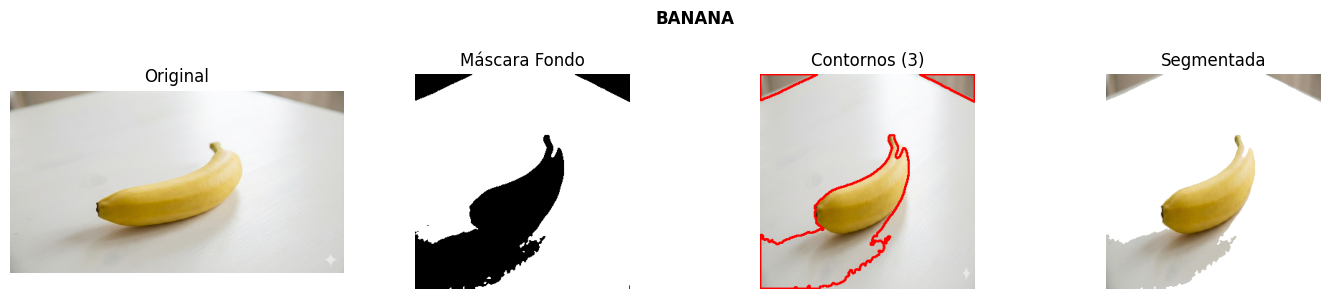

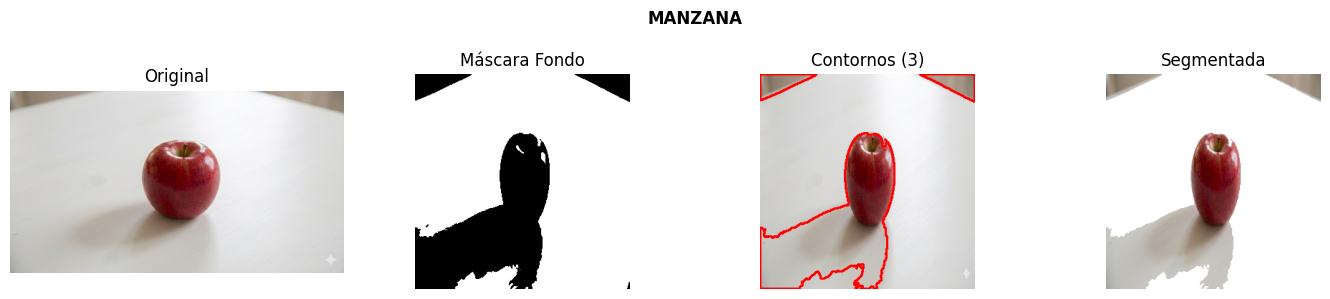

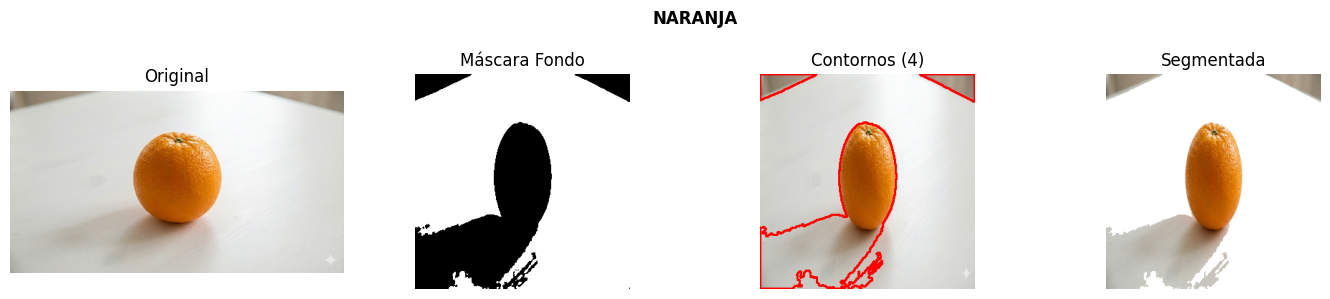

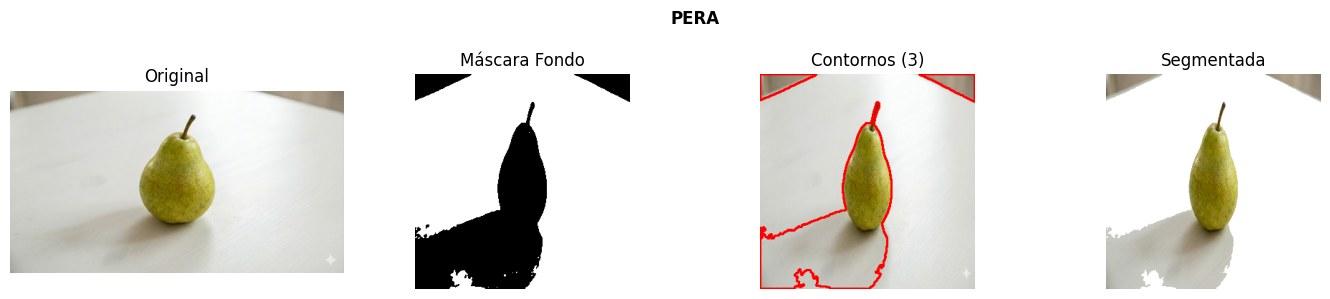

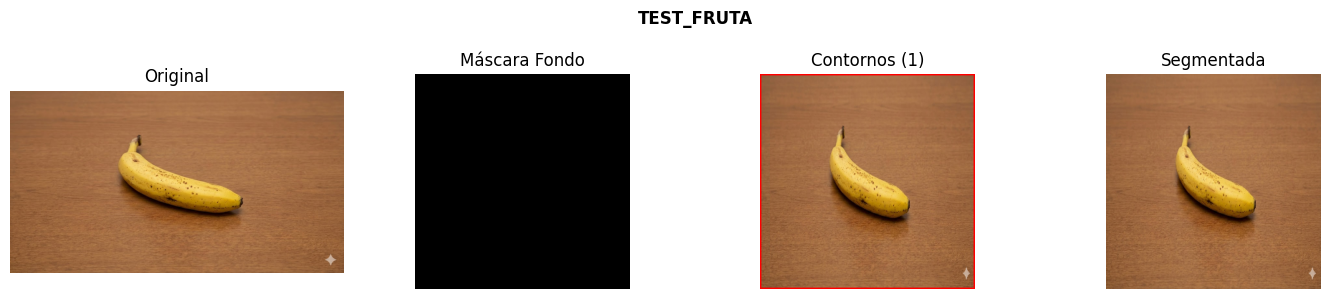

In [11]:
def show_segmentation_results(rgb_original, label, idx=0):
    """Muestra el proceso completo de segmentación para una imagen."""
    
    # Procesar imagen
    rgb_prep, hsv_prep, _ = preprocess_image(rgb_original)
    
    # Segmentación
    mask_bg = create_background_mask(hsv_prep)
    mask_fg = 255 - mask_bg
    
    # Contornos
    segmented, mask_final, contours = filter_contours_and_segment(rgb_prep, mask_fg, min_area=500)
    
    # Dibujar contornos en la imagen original
    rgb_with_contours = rgb_prep.copy()
    cv2.drawContours(rgb_with_contours, contours, -1, (255, 0, 0), 2)
    
    # Mostrar
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    fig.suptitle(f"{label.upper()}", fontsize=12, fontweight='bold')
    
    axes[0].imshow(rgb_original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(mask_bg, cmap='gray')
    axes[1].set_title("Máscara Fondo")
    axes[1].axis('off')
    
    axes[2].imshow(rgb_with_contours)
    axes[2].set_title(f"Contornos ({len(contours)})")
    axes[2].axis('off')
    
    axes[3].imshow(segmented)
    axes[3].set_title("Segmentada")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()


# Mostrar resultados para una imagen de cada clase
classes_to_show = np.unique(labels)
for clase in classes_to_show[:5]:  # Mostrar primeras 2 clases
    idx = np.where(np.array(labels) == clase)[0][0]
    show_segmentation_results(images[idx], labels[idx], idx)

## 8️⃣ Análisis de Características por Fruta

In [8]:
def process_all_images():
    """Procesa todas las imágenes y extrae características."""
    
    all_features = []
    
    print("Procesando todas las imágenes...\n")
    
    for idx, (rgb_img, label) in enumerate(zip(images, labels)):
        # Procesar imagen
        rgb_prep, hsv_prep, _ = preprocess_image(rgb_img)
        
        # Segmentación
        mask_bg = create_background_mask(hsv_prep)
        mask_fg = 255 - mask_bg
        segmented, mask_final, contours = filter_contours_and_segment(rgb_prep, mask_fg, min_area=500)
        
        # Extraer características del contorno más grande
        if len(contours) > 0:
            # Usar el contorno con mayor área
            contour = max(contours, key=cv2.contourArea)
            features = extract_features(rgb_prep, hsv_prep, mask_final, contour)
            
            # Crear vector de características simple
            feature_vector = np.concatenate([
                [features['aspect_ratio'], features['area'], features['perimeter'], 
                 features['circularity'], features['hue_mean'], features['sat_mean'], 
                 features['val_mean']],
                features['hu_moments'],
                features['hist_h']
            ])
            
            all_features.append({
                'label': label,
                'features': feature_vector,
                'properties': features
            })
    
    print(f"✓ {len(all_features)} imágenes procesadas exitosamente")
    return all_features


# Procesar todas las imágenes
all_features = process_all_images()

# Mostrar estadísticas por clase
print("\nEstadísticas por clase:")
for clase in np.unique(labels):
    class_features = [f for f in all_features if f['label'] == clase]
    print(f"\n{clase.upper()}: {len(class_features)} imágenes")
    
    if len(class_features) > 0:
        print(f"  Aspect Ratio - Media: {np.mean([f['properties']['aspect_ratio'] for f in class_features]):.2f}")
        print(f"  Circularidad - Media: {np.mean([f['properties']['circularity'] for f in class_features]):.3f}")
        print(f"  Hue Mean - Media: {np.mean([f['properties']['hue_mean'] for f in class_features]):.1f}")

Procesando todas las imágenes...

✓ 5 imágenes procesadas exitosamente

Estadísticas por clase:

BANANA: 1 imágenes
  Aspect Ratio - Media: 0.97
  Circularidad - Media: 0.290
  Hue Mean - Media: 23.7

MANZANA: 1 imágenes
  Aspect Ratio - Media: 0.86
  Circularidad - Media: 0.302
  Hue Mean - Media: 46.0

NARANJA: 1 imágenes
  Aspect Ratio - Media: 0.82
  Circularidad - Media: 0.325
  Hue Mean - Media: 19.9

PERA: 1 imágenes
  Aspect Ratio - Media: 0.70
  Circularidad - Media: 0.269
  Hue Mean - Media: 27.6

TEST_FRUTA: 1 imágenes
  Aspect Ratio - Media: 1.00
  Circularidad - Media: 0.785
  Hue Mean - Media: 13.3


## 9️⃣ Visualización 3D de Características Principales

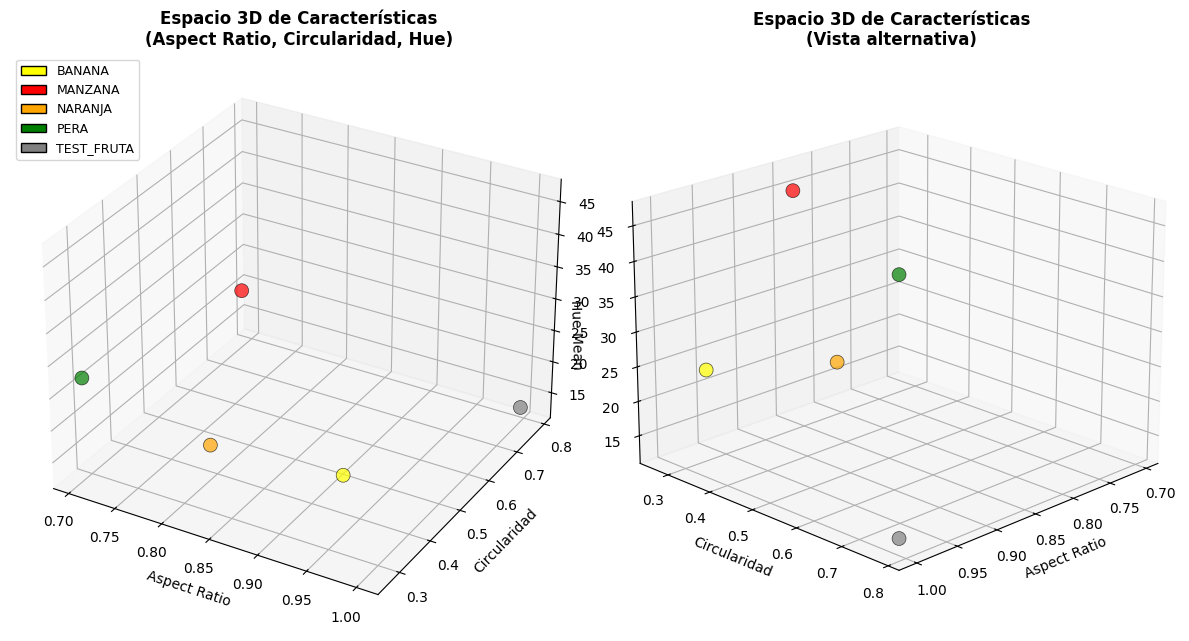


Resumen de características por clase:

Clase        Aspect Ratio    Circularidad    Hue Mean    
BANANA       0.967           0.290           23.7        
MANZANA      0.862           0.302           46.0        
NARANJA      0.820           0.325           19.9        
PERA         0.705           0.269           27.6        
TEST_FRUTA   1.000           0.785           13.3        


In [10]:
from mpl_toolkits.mplot3d import Axes3D

# Extraer características principales para visualización 3D
aspect_ratios = []
circularities = []
hue_means = []
all_labels = []

for feature_dict in all_features:
    props = feature_dict['properties']
    aspect_ratios.append(props['aspect_ratio'])
    circularities.append(props['circularity'])
    hue_means.append(props['hue_mean'])
    all_labels.append(feature_dict['label'])

# Colores por clase (con manejo robusto)
colors_map = {'manzana': 'red', 'banana': 'yellow', 'pera': 'green', 'naranja': 'orange'}
colors = [colors_map.get(label, 'gray') for label in all_labels]

# Crear figura 3D
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(aspect_ratios, circularities, hue_means, 
                      c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Aspect Ratio', fontsize=10)
ax1.set_ylabel('Circularidad', fontsize=10)
ax1.set_zlabel('Hue Mean', fontsize=10)
ax1.set_title('Espacio 3D de Características\n(Aspect Ratio, Circularidad, Hue)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Crear leyenda personalizada (solo para clases presentes)
from matplotlib.patches import Patch
unique_classes = np.unique(all_labels)
legend_elements = []
for clase in sorted(unique_classes):
    color = colors_map.get(clase, 'gray')
    legend_elements.append(Patch(facecolor=color, edgecolor='black', label=clase.upper()))

ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)

# Gráfico 2: Vista desde otro ángulo
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(aspect_ratios, circularities, hue_means, 
                       c=colors, s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Aspect Ratio', fontsize=10)
ax2.set_ylabel('Circularidad', fontsize=10)
ax2.set_zlabel('Hue Mean', fontsize=10)
ax2.set_title('Espacio 3D de Características\n(Vista alternativa)', fontsize=12, fontweight='bold')
ax2.view_init(elev=20, azim=45)  # Cambiar ángulo de visualización
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar tabla resumen de características
print("\nResumen de características por clase:\n")
print(f"{'Clase':<12} {'Aspect Ratio':<15} {'Circularidad':<15} {'Hue Mean':<12}")
print("="*55)

for clase in sorted(np.unique(all_labels)):
    class_features = [f for f in all_features if f['label'] == clase]
    if len(class_features) > 0:
        ar_mean = np.mean([f['properties']['aspect_ratio'] for f in class_features])
        circ_mean = np.mean([f['properties']['circularity'] for f in class_features])
        hue_mean_val = np.mean([f['properties']['hue_mean'] for f in class_features])
        
        print(f"{clase.upper():<12} {ar_mean:<15.3f} {circ_mean:<15.3f} {hue_mean_val:<12.1f}")